In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from jaxtyping import Float
from transformer_lens import HookedTransformer, HookedTransformerConfig

from muutils.dbg import dbg_tensor
from muutils.tensor_info import array_summary

In [2]:
MODEL: HookedTransformer = HookedTransformer.from_pretrained("gpt2-small")

Loaded pretrained model gpt2-small into HookedTransformer


In [ ]:
# prompt: str = "The quick brown fox jumps over the lazy dog."
prompt: str = "The quick brown fox jumps over the quick brown fox."
prompt: str = "The quick brown fox jumps over the other quick brown fox."
logits, cache = MODEL.run_with_cache(prompt)
prompt_tokens: list[str] = MODEL.tokenizer.tokenize(prompt)
prompt_tokens = [
	x.replace("Ġ", " ")
	for x in prompt_tokens
]
print(prompt_tokens)

['The', ' quick', ' brown', ' fox', ' jumps', ' over', ' the', ' quick', ' brown', ' fox', '.']


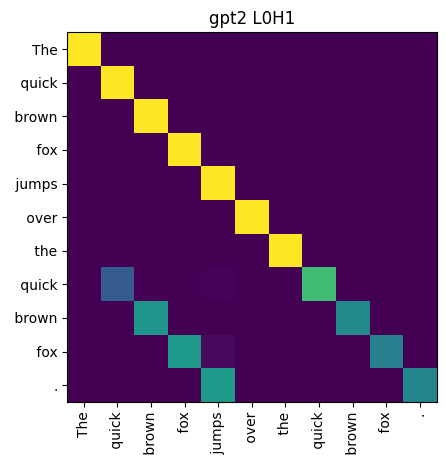

Saved 'figures/gpt2-L0H1.pdf'


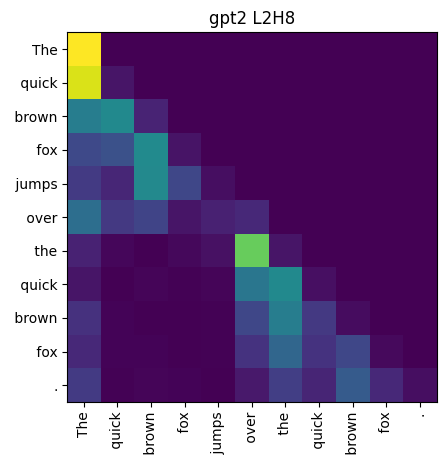

Saved 'figures/gpt2-L2H8.pdf'


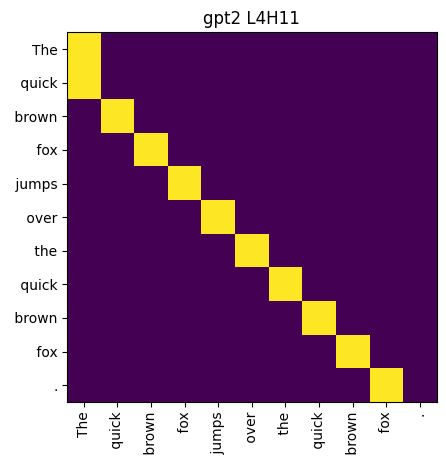

Saved 'figures/gpt2-L4H11.pdf'


In [22]:
save_heads: set[tuple[int, int]] = {
	(0, 1),
	(2,8),
	(4,11),
}

for layer_idx in range(MODEL.cfg.n_layers):
	for head_idx in range(MODEL.cfg.n_heads):
		if (layer_idx, head_idx) not in save_heads:
			continue
		pattern = cache[f"blocks.{layer_idx}.attn.hook_pattern"][0, head_idx]
		pattern = pattern[:-1, :-1] # trim end of text token
		fig, ax = plt.subplots()
		ax.imshow(pattern.cpu().numpy())
		ax.set_xticks(range(len(prompt_tokens)))
		ax.set_yticks(range(len(prompt_tokens)))
		ax.set_yticklabels(prompt_tokens)
		ax.set_xticklabels(prompt_tokens, rotation=90)
		ax.set_title(f"{MODEL.cfg.model_name} L{layer_idx}H{head_idx}")
		plt.show()
		if (layer_idx, head_idx) in save_heads:
			fname: str = f"figures/{MODEL.cfg.model_name}-L{layer_idx}H{head_idx}.pdf"
			fig.savefig(fname)
			print(f"Saved '{fname}'")